In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
CLEAN_PATH = None
for cand in [
    Path("../../datasets/processed/clean_sales.csv"),
    Path("../datasets/processed/clean_sales.csv"),
    Path("datasets/processed/clean_sales.csv"),
]:
    if cand.exists():
        CLEAN_PATH = cand.resolve()
        break

if CLEAN_PATH is None:
    raise FileNotFoundError(
        "clean_sales.csv not found. Run 02_preprocessing.ipynb first."
    )

PROCESSED_DIR = CLEAN_PATH.parent
FEATURES_PATH = PROCESSED_DIR / "features.csv"

print(f"📂 Input : {CLEAN_PATH}")
print(f"📂 Output: {FEATURES_PATH}")

📂 Input : C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\clean_sales.csv
📂 Output: C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features.csv


In [3]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Splits : {df['split'].value_counts().to_dict() if 'split' in df.columns else 'N/A'}")
df.head(2)

Loaded: 300,000 rows × 56 cols
Date   : 2021-01-01 → 2023-12-31
Splits : {'train': 209956, 'test': 45065, 'val': 44979}


,sale_id,invoice_number,date,split,store_id,store_name,city,state,product_id,sku,product_name,category,brand,supplier,cost_price,selling_price,quantity_sold,revenue,profit,profit_margin,is_loss_price,current_stock,reorder_level,stockout_flag,promotion,...,day_of_week,day_of_week_num,week_of_year,month,quarter,year,season,is_weekend,is_month_start,is_month_end,weather,customer_type,payment_method,category_enc,brand_enc,supplier_enc,promotion_enc,holiday_enc,festival_enc,season_enc,weather_enc,customer_type_enc,payment_method_enc,city_enc,state_enc
0,1,INV-2021-97240,2021-01-01,train,1,SmartRetail Mumbai,Mumbai,Maharashtra,129,SKU-BOO-0129,DailyFresh Book 129,Books,DailyFresh,Supplier_West,623.10,873.21,3,"2,619.63",750.33,0.29,0,130,41,0,NaN,...,Friday,4,53,1,1,2021,Winter,0,1,0,Foggy,Member,Credit Card,0,5,4,4,4,4,3,3,0,1,6,3
1,171,INV-2022-41838,2021-01-01,train,7,SmartRetail Kolkata,Kolkata,West Bengal,111,SKU-TOY-0111,TechPro Toy 111,Toys,TechPro,Supplier_South,"2,263.50","3,921.79",4,"7,843.58","-1,210.42",-0.15,0,39,10,0,BOGO,...,Friday,4,53,1,1,2021,Winter,0,1,0,Cold,New,Credit Card,7,7,3,2,4,4,3,2,1,1,5,7


In [4]:
# One row per day = target series for demand / revenue forecast
daily = df.groupby(df["date"].dt.normalize()).agg(
    # targets
    y_revenue=("revenue", "sum"),
    y_quantity=("quantity_sold", "sum"),
    y_profit=("profit", "sum"),
    y_transactions=("sale_id", "count"),
    # business signals (same day)
    promo_share=("is_promo", "mean") if "is_promo" in df.columns else ("revenue", "size"),
    festival_share=("is_festival", "mean") if "is_festival" in df.columns else ("revenue", "size"),
    holiday_share=("is_holiday", "mean") if "is_holiday" in df.columns else ("revenue", "size"),
    avg_discount=("discount_percent", "mean"),
    avg_stock=("current_stock", "mean"),
    stockout_share=("stockout_flag", "mean") if "stockout_flag" in df.columns else ("revenue", "size"),
    n_stores=("store_id", "nunique"),
    n_products=("product_id", "nunique"),
).reset_index().rename(columns={"date": "ds"})

daily["ds"] = pd.to_datetime(daily["ds"])
daily = daily.sort_values("ds").reset_index(drop=True)

# Primary target for models (change to y_quantity if you prefer units)
daily["y"] = daily["y_revenue"]

print(f"Daily rows: {len(daily):,}")
print(f"Range     : {daily['ds'].min().date()} → {daily['ds'].max().date()}")
daily.head()

Daily rows: 1,095
Range     : 2021-01-01 → 2023-12-31


,ds,y_revenue,y_quantity,y_profit,y_transactions,promo_share,festival_share,holiday_share,avg_discount,avg_stock,stockout_share,n_stores,n_products,y
0,2021-01-01,"8,313,633.57",920,"1,962,948.07",268,0.44,0.00,0.00,0.13,105.81,0.01,10,142,"8,313,633.57"
1,2021-01-02,"12,268,574.07",1423,"2,775,266.50",281,0.53,0.00,0.00,0.14,102.41,0.00,10,158,"12,268,574.07"
2,2021-01-03,"10,290,834.14",1323,"1,954,827.33",255,0.53,0.00,0.00,0.15,104.15,0.00,10,142,"10,290,834.14"
3,2021-01-04,"6,684,233.86",872,"1,479,648.69",283,0.52,0.00,0.00,0.14,98.44,0.01,10,153,"6,684,233.86"
4,2021-01-05,"8,272,067.09",911,"2,271,066.77",271,0.44,0.00,0.00,0.12,109.15,0.01,10,149,"8,272,067.09"


In [5]:
# Continuous daily index so lag_7 always means "7 days ago"
full_idx = pd.date_range(daily["ds"].min(), daily["ds"].max(), freq="D")
daily = daily.set_index("ds").reindex(full_idx).rename_axis("ds").reset_index()

# Fill numeric gaps (days with zero sales)
num_fill_zero = [
    "y_revenue", "y_quantity", "y_profit", "y_transactions",
    "promo_share", "festival_share", "holiday_share",
    "avg_discount", "stockout_share", "n_stores", "n_products",
]
for c in num_fill_zero:
    if c in daily.columns:
        daily[c] = daily[c].fillna(0.0)

if "avg_stock" in daily.columns:
    daily["avg_stock"] = daily["avg_stock"].ffill().bfill()

daily["y"] = daily["y_revenue"]

print(f"After reindex: {len(daily):,} days")
print(f"Zero-sales days: {(daily['y_transactions'] == 0).sum():,}")

After reindex: 1,095 days
Zero-sales days: 0


In [6]:
daily["year"] = daily["ds"].dt.year
daily["month"] = daily["ds"].dt.month
daily["day"] = daily["ds"].dt.day
daily["day_of_week"] = daily["ds"].dt.dayofweek          # 0=Mon … 6=Sun
daily["week_of_year"] = daily["ds"].dt.isocalendar().week.astype(int)
daily["quarter"] = daily["ds"].dt.quarter
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)
daily["is_month_start"] = daily["ds"].dt.is_month_start.astype(int)
daily["is_month_end"] = daily["ds"].dt.is_month_end.astype(int)

# Cyclical encoding (helps linear models; trees also ok)
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["dow_sin"] = np.sin(2 * np.pi * daily["day_of_week"] / 7)
daily["dow_cos"] = np.cos(2 * np.pi * daily["day_of_week"] / 7)

print("Time features added:")
print([c for c in daily.columns if c in [
    "year", "month", "day", "day_of_week", "week_of_year", "quarter",
    "is_weekend", "is_month_start", "is_month_end",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
]])
daily[["ds", "y", "month", "day_of_week", "is_weekend"]].head()

Time features added:
['year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


,ds,y,month,day_of_week,is_weekend
0,2021-01-01,"8,313,633.57",1,4,0
1,2021-01-02,"12,268,574.07",1,5,1
2,2021-01-03,"10,290,834.14",1,6,1
3,2021-01-04,"6,684,233.86",1,0,0
4,2021-01-05,"8,272,067.09",1,1,0


In [7]:
# lag_k = value of y, k days ago
LAGS = [1, 7, 14, 30]

for lag in LAGS:
    daily[f"lag_{lag}"] = daily["y"].shift(lag)

# Also lag quantity (optional second signal)
for lag in [1, 7]:
    daily[f"lag_qty_{lag}"] = daily["y_quantity"].shift(lag)

print("Lag columns:", [c for c in daily.columns if c.startswith("lag_")])
daily[["ds", "y", "lag_1", "lag_7", "lag_14", "lag_30"]].head(10)

Lag columns: ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_qty_1', 'lag_qty_7']


,ds,y,lag_1,lag_7,lag_14,lag_30
0,2021-01-01,"8,313,633.57",NaN,NaN,NaN,NaN
1,2021-01-02,"12,268,574.07","8,313,633.57",NaN,NaN,NaN
2,2021-01-03,"10,290,834.14","12,268,574.07",NaN,NaN,NaN
3,2021-01-04,"6,684,233.86","10,290,834.14",NaN,NaN,NaN
4,2021-01-05,"8,272,067.09","6,684,233.86",NaN,NaN,NaN
5,2021-01-06,"7,238,711.80","8,272,067.09",NaN,NaN,NaN
6,2021-01-07,"6,272,896.66","7,238,711.80",NaN,NaN,NaN
7,2021-01-08,"5,991,149.58","6,272,896.66","8,313,633.57",NaN,NaN
8,2021-01-09,"11,305,922.46","5,991,149.58","12,268,574.07",NaN,NaN
9,2021-01-10,"8,433,889.63","11,305,922.46","10,290,834.14",NaN,NaN


In [8]:
# Rolling stats use past only (shift 1) → no leakage
WINDOWS = [7, 14, 30]

for w in WINDOWS:
    rolled = daily["y"].shift(1).rolling(window=w, min_periods=max(1, w // 2))
    daily[f"roll_mean_{w}"] = rolled.mean()
    daily[f"roll_std_{w}"] = rolled.std()
    daily[f"roll_min_{w}"] = rolled.min()
    daily[f"roll_max_{w}"] = rolled.max()

print("Rolling columns:", [c for c in daily.columns if c.startswith("roll_")])
daily[["ds", "y", "roll_mean_7", "roll_std_7", "roll_mean_30"]].tail(5)

Rolling columns: ['roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_mean_14', 'roll_std_14', 'roll_min_14', 'roll_max_14', 'roll_mean_30', 'roll_std_30', 'roll_min_30', 'roll_max_30']


,ds,y,roll_mean_7,roll_std_7,roll_mean_30
1090,2023-12-27,"5,799,247.03","10,006,074.84","5,440,746.44","8,654,003.82"
1091,2023-12-28,"9,024,600.38","9,653,764.04","5,648,141.30","8,580,437.41"
1092,2023-12-29,"7,410,304.65","10,169,993.51","5,353,165.74","8,573,650.46"
1093,2023-12-30,"8,874,061.96","10,285,403.05","5,271,519.31","8,617,824.11"
1094,2023-12-31,"10,791,541.17","9,905,553.62","5,262,427.54","8,708,593.92"


In [9]:
# Binary business flags from shares
daily["is_promo_day"] = (daily["promo_share"] > 0.05).astype(int)      # >5% promo txns
daily["is_festival_day"] = (daily["festival_share"] > 0).astype(int)
daily["is_holiday_day"] = (daily["holiday_share"] > 0).astype(int)
daily["high_discount_day"] = (daily["avg_discount"] >= 0.2).astype(int)
daily["high_stockout_day"] = (daily["stockout_share"] >= 0.1).astype(int)

# Interaction examples (simple, useful)
daily["weekend_x_promo"] = daily["is_weekend"] * daily["is_promo_day"]
daily["festival_x_promo"] = daily["is_festival_day"] * daily["is_promo_day"]

print("Business flags:",
      ["is_promo_day", "is_festival_day", "is_holiday_day",
       "high_discount_day", "high_stockout_day",
       "weekend_x_promo", "festival_x_promo"])

Business flags: ['is_promo_day', 'is_festival_day', 'is_holiday_day', 'high_discount_day', 'high_stockout_day', 'weekend_x_promo', 'festival_x_promo']


In [10]:
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Summer"
    if m in (6, 7, 8, 9):
        return "Monsoon"
    return "Autumn"

daily["season"] = daily["month"].map(month_to_season)

# Simple label encode season
season_map = {"Winter": 0, "Summer": 1, "Monsoon": 2, "Autumn": 3}
daily["season_enc"] = daily["season"].map(season_map).astype(int)

daily[["ds", "month", "season", "season_enc"]].drop_duplicates("month").sort_values("month")

,ds,month,season,season_enc
0,2021-01-01,1,Winter,0
31,2021-02-01,2,Winter,0
59,2021-03-01,3,Summer,1
90,2021-04-01,4,Summer,1
120,2021-05-01,5,Summer,1
151,2021-06-01,6,Monsoon,2
181,2021-07-01,7,Monsoon,2
212,2021-08-01,8,Monsoon,2
243,2021-09-01,9,Monsoon,2
273,2021-10-01,10,Autumn,3


In [11]:
meta_path = PROCESSED_DIR / "preprocess_meta.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    train_end = pd.Timestamp(meta["train_end"])
    val_end = pd.Timestamp(meta["val_end"])
    print(f"Using split from preprocess_meta.json")
else:
    # fallback: 70 / 15 / 15 by day count
    dates = daily["ds"].values
    n = len(dates)
    train_end = pd.Timestamp(dates[int(n * 0.70) - 1])
    val_end = pd.Timestamp(dates[int(n * 0.85) - 1])
    print("Meta not found — recomputed 70/15/15 split")

daily["split"] = "test"
daily.loc[daily["ds"] <= train_end, "split"] = "train"
daily.loc[(daily["ds"] > train_end) & (daily["ds"] <= val_end), "split"] = "val"

print(daily["split"].value_counts())
print(f"Train ≤ {train_end.date()} | Val ≤ {val_end.date()} | Test after")

Using split from preprocess_meta.json
split
train    766
test     165
val      164
Name: count, dtype: int64
Train ≤ 2023-02-05 | Val ≤ 2023-07-19 | Test after


In [12]:
before = len(daily)

# Need lag_30 + roll_30 → drop first ~30 days
feature_cols_check = [c for c in daily.columns if c.startswith(("lag_", "roll_"))]
daily = daily.dropna(subset=feature_cols_check).reset_index(drop=True)

print(f"Dropped warmup rows: {before - len(daily):,}")
print(f"Rows left: {len(daily):,}")

# Column groups for clarity
id_cols = ["ds", "split"]
target_cols = ["y", "y_revenue", "y_quantity", "y_profit", "y_transactions"]
time_cols = [
    "year", "month", "day", "day_of_week", "week_of_year", "quarter",
    "is_weekend", "is_month_start", "is_month_end",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "season", "season_enc",
]
lag_cols = [c for c in daily.columns if c.startswith("lag_")]
roll_cols = [c for c in daily.columns if c.startswith("roll_")]
biz_cols = [
    "promo_share", "festival_share", "holiday_share", "avg_discount",
    "avg_stock", "stockout_share", "n_stores", "n_products",
    "is_promo_day", "is_festival_day", "is_holiday_day",
    "high_discount_day", "high_stockout_day",
    "weekend_x_promo", "festival_x_promo",
]
biz_cols = [c for c in biz_cols if c in daily.columns]

ordered = id_cols + target_cols + time_cols + lag_cols + roll_cols + biz_cols
ordered = [c for c in ordered if c in daily.columns]
# any leftover
ordered += [c for c in daily.columns if c not in ordered]

features = daily[ordered].copy()
print(f"Feature matrix: {features.shape[0]:,} rows × {features.shape[1]} cols")
print("\nNulls:", features.isnull().sum().sum())
features.head(3)

Dropped warmup rows: 30
Rows left: 1,065
Feature matrix: 1,065 rows × 55 cols

Nulls: 0


,ds,split,y,y_revenue,y_quantity,y_profit,y_transactions,year,month,day,day_of_week,week_of_year,quarter,is_weekend,is_month_start,is_month_end,month_sin,month_cos,dow_sin,dow_cos,season,season_enc,lag_1,lag_7,lag_14,...,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30,promo_share,festival_share,holiday_share,avg_discount,avg_stock,stockout_share,n_stores,n_products,is_promo_day,is_festival_day,is_holiday_day,high_discount_day,high_stockout_day,weekend_x_promo,festival_x_promo
0,2021-01-31,train,"9,310,912.43","9,310,912.43",1509,"1,993,427.54",272,2021,1,31,6,4,1,1,0,1,0.50,0.87,-0.78,0.62,Winter,0,"12,122,649.11","9,204,756.02","14,388,028.82",...,"6,644,627.49","16,808,163.46","9,169,903.81","3,346,085.52","5,796,841.72","16,808,163.46","8,619,262.86","2,742,577.66","5,796,841.72","16,808,163.46",0.48,0.00,0.00,0.13,100.37,0.02,10,148,1,0,0,0,0,1,0
1,2021-02-01,train,"7,859,465.60","7,859,465.60",909,"1,770,156.16",273,2021,2,1,0,5,1,0,1,0,0.87,0.50,0.00,1.00,Winter,0,"9,310,912.43","6,644,627.49","7,103,263.55",...,"6,644,627.49","16,808,163.46","8,807,252.64","2,993,603.19","5,796,841.72","16,808,163.46","8,652,505.49","2,744,788.49","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,101.59,0.00,10,144,1,0,0,0,0,0,0
2,2021-02-02,train,"6,899,503.98","6,899,503.98",842,"1,348,847.95",246,2021,2,2,1,5,1,0,0,0,0.87,0.50,0.78,0.62,Winter,0,"7,859,465.60","16,808,163.46","7,941,847.63",...,"6,702,827.13","16,808,163.46","8,861,267.07","2,967,198.32","5,796,841.72","16,808,163.46","8,505,535.21","2,661,261.07","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,104.37,0.02,10,145,1,0,0,0,0,0,0


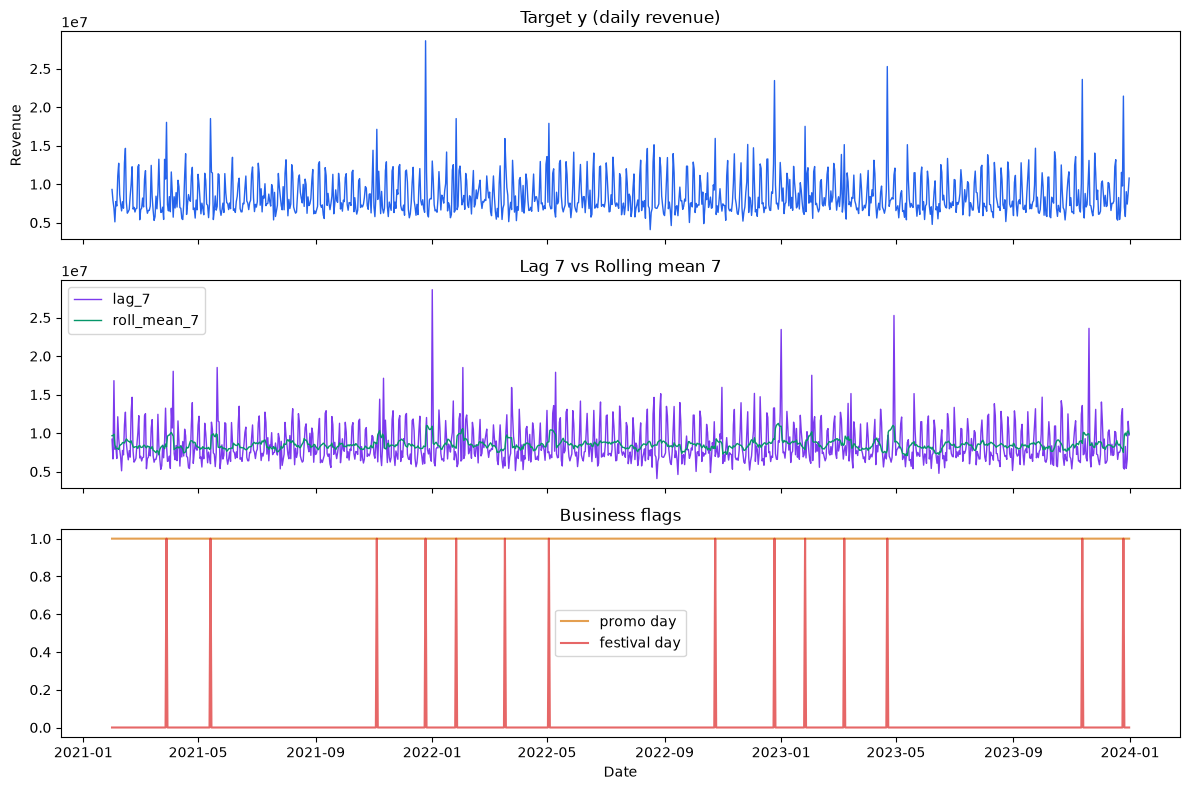

Feature list:
  • ds
  • split
  • y
  • y_revenue
  • y_quantity
  • y_profit
  • y_transactions
  • year
  • month
  • day
  • day_of_week
  • week_of_year
  • quarter
  • is_weekend
  • is_month_start
  • is_month_end
  • month_sin
  • month_cos
  • dow_sin
  • dow_cos
  • season
  • season_enc
  • lag_1
  • lag_7
  • lag_14
  • lag_30
  • lag_qty_1
  • lag_qty_7
  • roll_mean_7
  • roll_std_7
  • roll_min_7
  • roll_max_7
  • roll_mean_14
  • roll_std_14
  • roll_min_14
  • roll_max_14
  • roll_mean_30
  • roll_std_30
  • roll_min_30
  • roll_max_30
  • promo_share
  • festival_share
  • holiday_share
  • avg_discount
  • avg_stock
  • stockout_share
  • n_stores
  • n_products
  • is_promo_day
  • is_festival_day
  • is_holiday_day
  • high_discount_day
  • high_stockout_day
  • weekend_x_promo
  • festival_x_promo


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(features["ds"], features["y"], color="#2563eb", linewidth=1)
axes[0].set_title("Target y (daily revenue)"); axes[0].set_ylabel("Revenue")

axes[1].plot(features["ds"], features["lag_7"], color="#7c3aed", linewidth=1, label="lag_7")
axes[1].plot(features["ds"], features["roll_mean_7"], color="#059669", linewidth=1, label="roll_mean_7")
axes[1].legend(); axes[1].set_title("Lag 7 vs Rolling mean 7")

axes[2].plot(features["ds"], features["is_promo_day"], color="#d97706", alpha=0.7, label="promo day")
axes[2].plot(features["ds"], features["is_festival_day"], color="#dc2626", alpha=0.7, label="festival day")
axes[2].legend(); axes[2].set_title("Business flags"); axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

print("Feature list:")
for c in features.columns:
    print(f"  • {c}")

In [15]:
features.to_csv(FEATURES_PATH, index=False)
print(f"✅ Saved → {FEATURES_PATH}")
print(f"   Size  : {FEATURES_PATH.stat().st_size / 1024:.1f} KB")
print(f"   Shape : {features.shape[0]:,} × {features.shape[1]}")

feat_meta = {
    "n_rows": int(len(features)),
    "n_cols": int(features.shape[1]),
    "date_min": str(features["ds"].min().date()),
    "date_max": str(features["ds"].max().date()),
    "target": "y",  # = y_revenue
    "split_counts": features["split"].value_counts().to_dict(),
    "time_cols": time_cols,
    "lag_cols": lag_cols,
    "roll_cols": roll_cols,
    "biz_cols": biz_cols,
    "xgb_feature_cols": lag_cols + roll_cols + [
        c for c in time_cols + biz_cols
        if c not in ("season",)  # use season_enc instead of string
    ],
}
# clean xgb list to existing numeric-ish cols
feat_meta["xgb_feature_cols"] = [
    c for c in feat_meta["xgb_feature_cols"]
    if c in features.columns and c not in ("season",)
]

with open(PROCESSED_DIR / "features_meta.json", "w") as f:
    json.dump(feat_meta, f, indent=2)

print(f"✅ Meta  → {PROCESSED_DIR / 'features_meta.json'}")
print("\nNext → 04_prophet_training.ipynb  (uses ds, y + holidays)")
print("     → 05_xgboost_training.ipynb (uses xgb_feature_cols)")
display(feat_meta)

✅ Saved → C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features.csv
   Size  : 522.5 KB
   Shape : 1,065 × 55
✅ Meta  → C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features_meta.json

Next → 04_prophet_training.ipynb  (uses ds, y + holidays)
     → 05_xgboost_training.ipynb (uses xgb_feature_cols)


{'n_rows': 1065,
 'n_cols': 55,
 'date_min': '2021-01-31',
 'date_max': '2023-12-31',
 'target': 'y',
 'split_counts': {'train': 736, 'test': 165, 'val': 164},
 'time_cols': ['year',
  'month',
  'day',
  'day_of_week',
  'week_of_year',
  'quarter',
  'is_weekend',
  'is_month_start',
  'is_month_end',
  'month_sin',
  'month_cos',
  'dow_sin',
  'dow_cos',
  'season',
  'season_enc'],
 'lag_cols': ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_qty_1', 'lag_qty_7'],
 'roll_cols': ['roll_mean_7',
  'roll_std_7',
  'roll_min_7',
  'roll_max_7',
  'roll_mean_14',
  'roll_std_14',
  'roll_min_14',
  'roll_max_14',
  'roll_mean_30',
  'roll_std_30',
  'roll_min_30',
  'roll_max_30'],
 'biz_cols': ['promo_share',
  'festival_share',
  'holiday_share',
  'avg_discount',
  'avg_stock',
  'stockout_share',
  'n_stores',
  'n_products',
  'is_promo_day',
  'is_festival_day',
  'is_holiday_day',
  'high_discount_day',
  'high_stockout_day',
  'weekend_x_promo',
  'festival_x_promo'],
 'xgb_feature_